# Úkol 3: Evaluace a kritické srovnání modelů
## MML1 Projekt: Predikce doby průchodu Mythic+ dungeonem (Pit of Saron) podle složení skupiny

Výzkumná otázka: V rámci klíče +16, může složení skupiny (class a spec hráčů) předpovědět dobu průchodu Pit of Saron nad rámec toho, co vysvětluje průměrný item level skupiny?

Úloha je regresní (cíl `clear_time_ms` je spojitý), takže používám regresní metriky:

| Metrika | Význam | Lepší |
|---|---|---|
| RMSE (s) | odmocnina ze střední kvadratické chyby, penalizuje velké odchylky | nižší |
| MAE (s) | průměrná absolutní chyba, robustnější vůči odlehlým hodnotám | nižší |
| R² | podíl vysvětleného rozptylu (0 = na úrovni průměru, 1 = perfektní) | vyšší |

Klasifikační metriky ze zadání (Accuracy, F1, ROC AUC) se na regresi nevztahují. Ze stejného důvodu nezařazuji logistickou regresi, která je klasifikační. Jejím protějškem je tu obyčejná lineární regrese a její regularizované varianty Ridge a Lasso.

Jak postupuju při vyhodnocení:
- Hyperparametry ladím jen na validační sadě. Držím se tím chronologického splitu z `dataprocessing.ipynb`, protože náhodná křížová validace by propustila informaci o týdenních afixech.
- Finální čísla počítám na testovací sadě, kterou jsem dosud nepoužil.
- Každý model trénuji dvakrát, na feature setu `ilvl` (jen gear) a `full` (gear i složení). Porovnání obou přímo odpovídá na výzkumnou otázku.
- Baseline (`DummyRegressor`) je laťka, kterou by měl každý reálný model překonat.


## 1. Importy a načtení dat

Načítám chronologicky rozdělené sady z `data/` (výstup `dataprocessing.ipynb`). Soubory obsahují surové sloupce, preprocessing si proto sestavím znovu a fituji ho jen na trénovací sadě.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

%matplotlib inline
RANDOM_STATE = 42

train = pd.read_csv("data/train.csv")
validation = pd.read_csv("data/validation.csv")
test = pd.read_csv("data/test.csv")

print(f"Train:      {len(train):>5} runů")
print(f"Validation: {len(validation):>5} runů")
print(f"Test:       {len(test):>5} runů")

Train:       6111 runů
Validation:  1309 runů
Test:        1310 runů


## 2. Features a preprocessing

Definice sloupců přebírám z `dataprocessing.ipynb`. Funkce `prepare()` odstraní identifikátory, konstanty, jména a redundantní ID, dopočítá `avg_group_ilvl` a oddělí cíl.

Cíl počítám v sekundách (`clear_time_ms / 1000`), aby RMSE i MAE vyšly přímo v sekundách (R² je na škále nezávislé).

Používám dva feature sety:
- `ilvl`: jen gear, tedy `avg_group_ilvl` a 5 individuálních ilvl. Rozšiřuje benchmark z úkolu 2.
- `full`: gear i složení, tedy class, spec a race každé role, faction a týdenní afixy.

Každý model balím do pipeline (nejdřív preprocessor, pak samotný model) a navíc do `TransformedTargetRegressor`, který standardizuje cílovou proměnnou. Pro lineární a stromové modely i KNN je to neškodné, ale pro SVR je škála cíle zásadní, protože epsilon-trubice a regularizace `C` jsou citlivé na měřítko. Jednotné zabalení tak drží srovnání férové.

In [2]:
TARGET = "clear_time_ms"

COLUMNS_TO_DROP = [
    "keystone_run_id", "keystone_team_id", "completed_at", "season",
    "mythic_level", "keystone_time_ms",
    "dungeon_name", "dungeon_short_name", "dungeon_slug", "dungeon_patch",
    "tank_name", "healer_name", "dps_1_name", "dps_2_name", "dps_3_name",
    "tank_race_id", "tank_class_id", "tank_spec_id",
    "healer_race_id", "healer_class_id", "healer_spec_id",
    "dps_1_race_id", "dps_1_class_id", "dps_1_spec_id",
    "dps_2_race_id", "dps_2_class_id", "dps_2_spec_id",
    "dps_3_race_id", "dps_3_class_id", "dps_3_spec_id",
]
ILVL_COLUMNS = ["tank_ilvl", "healer_ilvl", "dps_1_ilvl", "dps_2_ilvl", "dps_3_ilvl"]
NUMERICAL_COLUMNS = ["avg_group_ilvl"] + ILVL_COLUMNS
CATEGORICAL_COLUMNS = [
    "faction", "modifier_1", "modifier_2", "modifier_3",
    "tank_race", "tank_class", "tank_spec",
    "healer_race", "healer_class", "healer_spec",
    "dps_1_race", "dps_1_class", "dps_1_spec",
    "dps_2_race", "dps_2_class", "dps_2_spec",
    "dps_3_race", "dps_3_class", "dps_3_spec",
]

def prepare(dataframe):
    # Odstraní nepotřebné sloupce, odvodí avg_group_ilvl, vrátí (features, target v sekundách).
    dataframe = dataframe.drop(columns=[col for col in COLUMNS_TO_DROP if col in dataframe.columns])
    for column in ILVL_COLUMNS:
        dataframe[column] = pd.to_numeric(dataframe[column], errors="coerce")
    dataframe["avg_group_ilvl"] = dataframe[ILVL_COLUMNS].mean(axis=1)
    target_seconds = dataframe.pop(TARGET) / 1000.0  # ms -> s
    return dataframe, target_seconds

features_train, target_train = prepare(train.copy())
features_validation, target_validation = prepare(validation.copy())
features_test, target_test = prepare(test.copy())

print(f"features_train: {features_train.shape}, features_validation: {features_validation.shape}, features_test: {features_test.shape}")
print(f"clear_time (s), train mean {target_train.mean():.1f}, std {target_train.std():.1f}")

features_train: (6111, 25), features_validation: (1309, 25), features_test: (1310, 25)
clear_time (s), train mean 1599.6, std 76.7


In [3]:
def make_preprocessor(categorical_columns):
    # ColumnTransformer: numerika (medián + scale), kategorie (konstanta + OHE).
    transformers = [
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler",  StandardScaler()),
        ]), NUMERICAL_COLUMNS),
    ]
    if categorical_columns:
        transformers.append(("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("ohe",     OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]), categorical_columns))
    return ColumnTransformer(transformers, remainder="drop")

# feature set -> seznam kategorických sloupců (numerika je vždy stejná)
FEATURE_SETS = {
    "ilvl": [],
    "full": CATEGORICAL_COLUMNS,
}

def build_pipeline(model, categorical_columns):
    # Preprocessor + model, zabaleno do TransformedTargetRegressor (standardizace cíle).
    pipeline = Pipeline([
        ("prep",  make_preprocessor(categorical_columns)),
        ("model", model),
    ])
    return TransformedTargetRegressor(regressor=pipeline, transformer=StandardScaler())

## 3. Pomocné funkce pro metriky

In [4]:
def regression_metrics(actual, predicted):
    return {
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),  # v sekundách
        "MAE":  mean_absolute_error(actual, predicted),
        "R2":   r2_score(actual, predicted),
    }

def rmse_seconds(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

## 4. Baseline model

`DummyRegressor(strategy="mean")` predikuje pro každý run průměrný čas z trénovací sady a ignoruje všechny features. Slouží jako referenční laťka. Jeho RMSE by mělo zhruba odpovídat směrodatné odchylce cíle na testu, což je zároveň kontrola, že mám metriky zapojené správně.

In [5]:
baseline = build_pipeline(DummyRegressor(strategy="mean"), categorical_columns=[])
baseline.fit(features_train, target_train)
baseline_test_metrics = regression_metrics(target_test, baseline.predict(features_test))

print("Baseline (DummyRegressor mean):")
print(f"  Test RMSE: {baseline_test_metrics['RMSE']:.1f} s  |  MAE: {baseline_test_metrics['MAE']:.1f} s  |  R2: {baseline_test_metrics['R2']:.3f}")
print(f"  Kontrola: std(target_test) = {target_test.std():.1f} s  (mělo by se blížit RMSE baseline)")

Baseline (DummyRegressor mean):
  Test RMSE: 87.9 s  |  MAE: 69.9 s  |  R2: -0.062
  Kontrola: std(target_test) = 85.3 s  (mělo by se blížit RMSE baseline)


## 5. Definice modelů a ladění hyperparametrů

Pro každý model mám malou mřížku kandidátů. Pro každý feature set vyberu konfiguraci s nejnižší RMSE na validační sadě a model natrénovaný na trénovací sadě pak vyhodnotím na testu. Mřížky držím malé, aby Restart & Run All proběhl rychle.

In [6]:
MODEL_GRID = {
    "Linear Regression": (LinearRegression, [{}]),
    "Ridge":             (Ridge, [{"alpha": alpha, "random_state": RANDOM_STATE} for alpha in [0.1, 1, 10, 100, 1000]]),
    "Lasso":             (Lasso, [{"alpha": alpha, "max_iter": 20000, "random_state": RANDOM_STATE} for alpha in [0.001, 0.01, 0.1, 1]]),
    "Decision Tree":     (DecisionTreeRegressor, [
                            {"max_depth": depth, "min_samples_leaf": leaf, "random_state": RANDOM_STATE}
                            for depth in [3, 5, 8, 12, None] for leaf in [1, 5, 20]]),
    "Random Forest":     (RandomForestRegressor, [
                            {"n_estimators": 300, "max_depth": depth, "min_samples_leaf": leaf,
                             "random_state": RANDOM_STATE, "n_jobs": -1}
                            for depth in [None, 16] for leaf in [1, 5]]),
    "SVR":               (SVR, [{"C": regularization, "gamma": "scale"} for regularization in [1, 10, 100]]),
    "KNN":               (KNeighborsRegressor, [{"n_neighbors": neighbors} for neighbors in [5, 15, 30, 50]]),
}

## 6. Trénink a evaluace všech modelů

Dvojitá smyčka přes feature sety a modely. Pro každou kombinaci vyberu nejlepší hyperparametry na validaci a uložím trénovací (kvůli diagnostice overfittingu) i testovací metriky.

In [7]:
records = []
best_estimators = {}        # (feature_set, model_name) -> natrénovaný estimator
chosen_hyperparams = {}     # (feature_set, model_name) -> zvolené hyperparametry

for feature_set_name, categorical_columns in FEATURE_SETS.items():
    for model_name, (model_class, grid) in MODEL_GRID.items():
        # --- výběr hyperparametrů podle validační RMSE ---
        best_validation_rmse = None
        best_params = None
        best_estimator = None
        for params in grid:
            estimator = build_pipeline(model_class(**params), categorical_columns)
            estimator.fit(features_train, target_train)
            validation_rmse = rmse_seconds(target_validation, estimator.predict(features_validation))
            if best_validation_rmse is None or validation_rmse < best_validation_rmse:
                best_validation_rmse = validation_rmse
                best_params = params
                best_estimator = estimator

        train_metrics = regression_metrics(target_train, best_estimator.predict(features_train))
        test_metrics = regression_metrics(target_test, best_estimator.predict(features_test))

        best_estimators[(feature_set_name, model_name)] = best_estimator
        chosen_hyperparams[(feature_set_name, model_name)] = best_params
        records.append({
            "feature_set": feature_set_name, "model": model_name,
            "val_RMSE": round(best_validation_rmse, 1),
            "train_RMSE": round(train_metrics["RMSE"], 1), "test_RMSE": round(test_metrics["RMSE"], 1),
            "test_MAE": round(test_metrics["MAE"], 1), "test_R2": round(test_metrics["R2"], 3),
            "train_R2": round(train_metrics["R2"], 3),
        })

# baseline jako řádek navíc (nezávislý na feature setu)
baseline_train_metrics = regression_metrics(target_train, baseline.predict(features_train))
records.insert(0, {
    "feature_set": "-", "model": "Baseline (mean)",
    "val_RMSE": round(rmse_seconds(target_validation, baseline.predict(features_validation)), 1),
    "train_RMSE": round(baseline_train_metrics["RMSE"], 1), "test_RMSE": round(baseline_test_metrics["RMSE"], 1),
    "test_MAE": round(baseline_test_metrics["MAE"], 1), "test_R2": round(baseline_test_metrics["R2"], 3),
    "train_R2": round(baseline_train_metrics["R2"], 3),
})

results = pd.DataFrame(records)
print("Zvolené hyperparametry (podle validace):")
for key, params in chosen_hyperparams.items():
    print(f"  {key[0]:>5} | {key[1]:<18} {params}")

Zvolené hyperparametry (podle validace):
   ilvl | Linear Regression  {}
   ilvl | Ridge              {'alpha': 0.1, 'random_state': 42}
   ilvl | Lasso              {'alpha': 0.001, 'max_iter': 20000, 'random_state': 42}
   ilvl | Decision Tree      {'max_depth': 3, 'min_samples_leaf': 5, 'random_state': 42}
   ilvl | Random Forest      {'n_estimators': 300, 'max_depth': 16, 'min_samples_leaf': 5, 'random_state': 42, 'n_jobs': -1}
   ilvl | SVR                {'C': 1, 'gamma': 'scale'}
   ilvl | KNN                {'n_neighbors': 50}
   full | Linear Regression  {}
   full | Ridge              {'alpha': 100, 'random_state': 42}
   full | Lasso              {'alpha': 0.001, 'max_iter': 20000, 'random_state': 42}
   full | Decision Tree      {'max_depth': 3, 'min_samples_leaf': 5, 'random_state': 42}
   full | Random Forest      {'n_estimators': 300, 'max_depth': 16, 'min_samples_leaf': 5, 'random_state': 42, 'n_jobs': -1}
   full | SVR                {'C': 1, 'gamma': 'scale'}
   full 

## 7. Tabulka výsledků

Seřazeno podle testovací RMSE (nižší = lepší). Baseline je referenční laťka.

In [8]:
results_sorted = results.sort_values("test_RMSE").reset_index(drop=True)
results_sorted

,feature_set,model,val_RMSE,train_RMSE,test_RMSE,test_MAE,test_R2,train_R2
0,full,Random Forest,85.2,55.1,83.4,69.4,0.043,0.484
1,full,SVR,84.9,60.9,84.2,68.3,0.026,0.369
2,full,KNN,87.4,73.8,84.3,68.5,0.023,0.075
3,ilvl,SVR,85.2,75.9,84.6,69.7,0.017,0.021
4,ilvl,KNN,87.0,74.4,85.8,71.3,-0.013,0.058
5,full,Ridge,87.0,73.2,86.1,68.0,-0.019,0.089
6,full,Lasso,87.2,73.2,86.2,68.3,-0.022,0.089
7,full,Decision Tree,88.7,74.8,86.4,71.3,-0.026,0.048
8,ilvl,Decision Tree,88.4,75.0,86.6,72.1,-0.032,0.045
9,ilvl,Linear Regression,88.8,76.3,86.9,69.6,-0.037,0.010


In [9]:
# Přehledný pivot: model x feature set, testovací RMSE
pivot_rmse = (results[results["model"] != "Baseline (mean)"]
              .pivot(index="model", columns="feature_set", values="test_RMSE")
              .sort_values("full"))
print("Testovací RMSE (s), ilvl vs full feature set:")
print(pivot_rmse.to_string())
print(f"\nBaseline test RMSE: {baseline_test_metrics['RMSE']:.1f} s")

Testovací RMSE (s), ilvl vs full feature set:
feature_set        full  ilvl
model                        
Random Forest      83.4  88.7
SVR                84.2  84.6
KNN                84.3  85.8
Ridge              86.1  86.9
Lasso              86.2  86.9
Decision Tree      86.4  86.6
Linear Regression  87.1  86.9

Baseline test RMSE: 87.9 s


## 8. Vizualizace

### 8.1 Testovací RMSE podle modelu a feature setu

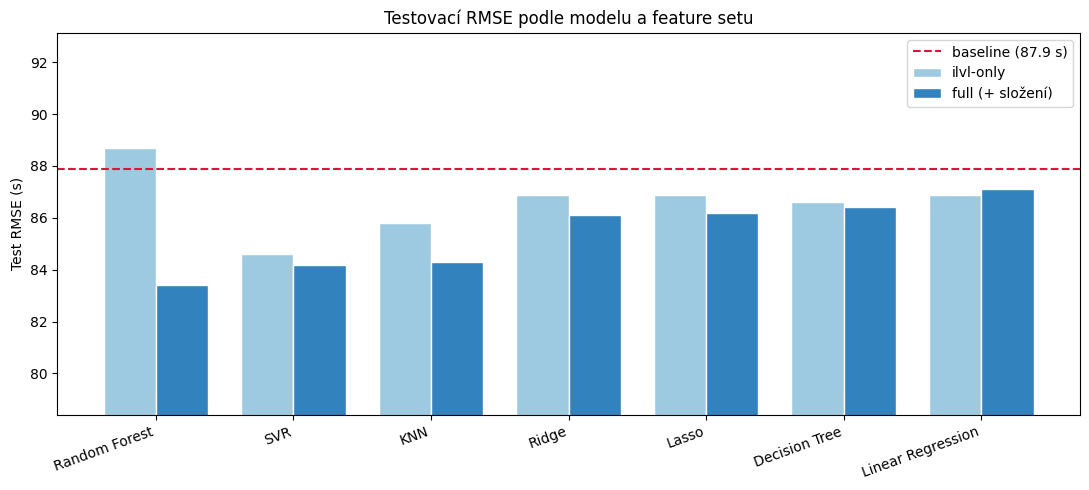

In [10]:
figure, axis = plt.subplots(figsize=(11, 5))
models_order = pivot_rmse.index.tolist()
positions = np.arange(len(models_order))
bar_width = 0.38
axis.bar(positions - bar_width/2, pivot_rmse["ilvl"], bar_width, label="ilvl-only", color="#9ecae1", edgecolor="white")
axis.bar(positions + bar_width/2, pivot_rmse["full"], bar_width, label="full (+ složení)", color="#3182bd", edgecolor="white")
axis.axhline(baseline_test_metrics["RMSE"], color="crimson", ls="--", lw=1.5,
             label=f"baseline ({baseline_test_metrics['RMSE']:.1f} s)")
axis.set_xticks(positions); axis.set_xticklabels(models_order, rotation=20, ha="right")
axis.set_ylabel("Test RMSE (s)"); axis.set_title("Testovací RMSE podle modelu a feature setu")
axis.set_ylim(bottom=min(pivot_rmse.min().min(), baseline_test_metrics["RMSE"]) - 5)
axis.legend()
plt.tight_layout(); plt.show()

### 8.2 Overfitting: train vs test RMSE (full feature set)

Velká mezera mezi trénovací a testovací RMSE značí přeučení, model se naučil šum trénovacích dat.

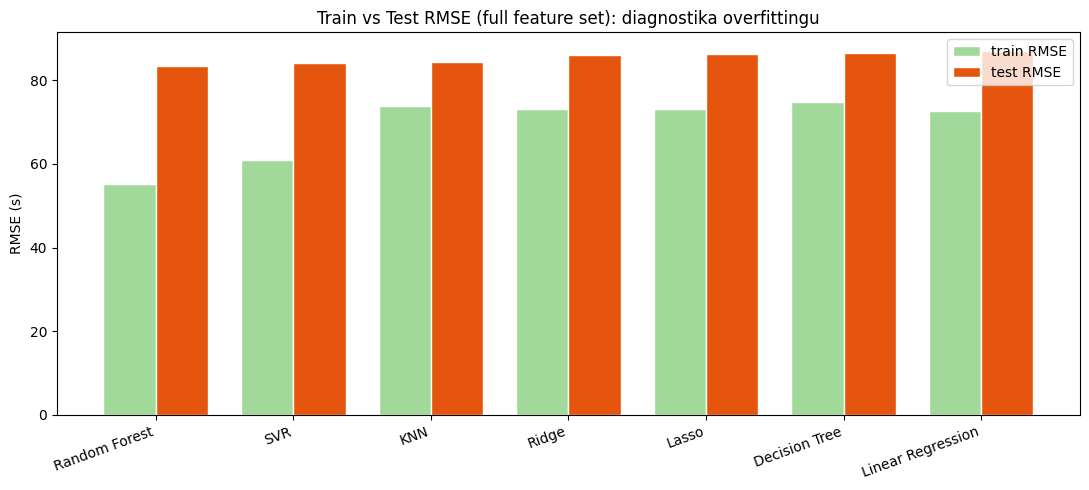

In [11]:
full_rows = results[results["feature_set"] == "full"].set_index("model")
models_order = full_rows.sort_values("test_RMSE").index.tolist()
positions = np.arange(len(models_order))
bar_width = 0.38
figure, axis = plt.subplots(figsize=(11, 5))
axis.bar(positions - bar_width/2, full_rows.loc[models_order, "train_RMSE"], bar_width,
         label="train RMSE", color="#a1d99b", edgecolor="white")
axis.bar(positions + bar_width/2, full_rows.loc[models_order, "test_RMSE"], bar_width,
         label="test RMSE", color="#e6550d", edgecolor="white")
axis.set_xticks(positions); axis.set_xticklabels(models_order, rotation=20, ha="right")
axis.set_ylabel("RMSE (s)"); axis.set_title("Train vs Test RMSE (full feature set): diagnostika overfittingu")
axis.legend(); plt.tight_layout(); plt.show()

### 8.3 Nejlepší model: predikce vs skutečnost (test)

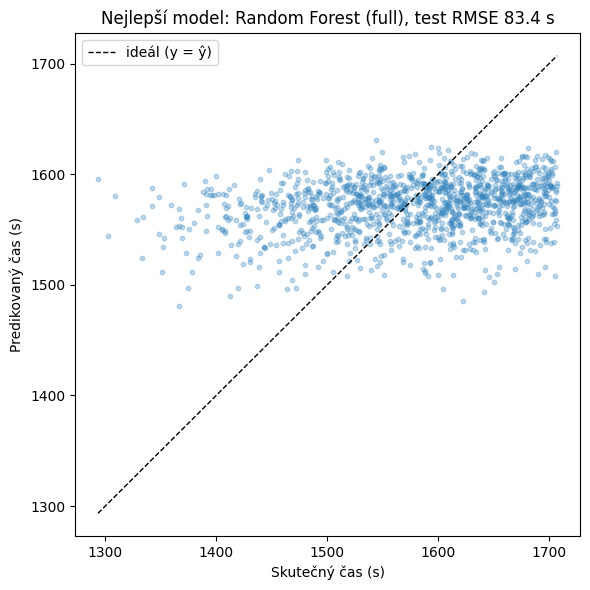

Nejlepší model: Random Forest | feature set: full | test R2 = 0.043


In [12]:
best_row = results_sorted[results_sorted["model"] != "Baseline (mean)"].iloc[0]
best_key = (best_row["feature_set"], best_row["model"])
best_estimator = best_estimators[best_key]
predicted_test = best_estimator.predict(features_test)

figure, axis = plt.subplots(figsize=(6, 6))
axis.scatter(target_test, predicted_test, s=10, alpha=0.3, color="#3182bd")
axis_limits = [min(target_test.min(), predicted_test.min()), max(target_test.max(), predicted_test.max())]
axis.plot(axis_limits, axis_limits, "k--", lw=1, label="ideál (y = ŷ)")
axis.set_xlabel("Skutečný čas (s)"); axis.set_ylabel("Predikovaný čas (s)")
axis.set_title(f"Nejlepší model: {best_key[1]} ({best_key[0]}), test RMSE {best_row['test_RMSE']} s")
axis.legend(); plt.tight_layout(); plt.show()
print(f"Nejlepší model: {best_key[1]} | feature set: {best_key[0]} | test R2 = {best_row['test_R2']}")

### 8.4 Interpretace: nese složení skupiny signál?

Vypíšu koeficienty Ridge (full) a feature importance Random Forest (full). U Ridge jsou koeficienty ve standardizované škále cíle, takže sleduji hlavně relativní velikost a znaménko. Zajímá mě, jestli se mezi nejsilnějšími features objeví i class a spec sloupce, nebo dominuje jen ilvl.

In [13]:
def feature_names(estimator):
    return estimator.regressor_.named_steps["prep"].get_feature_names_out()

def top_features(names, values, top_k=15):
    series = pd.Series(values, index=names)
    return series.reindex(series.abs().sort_values(ascending=False).index).head(top_k)

# Ridge koeficienty
ridge_estimator = best_estimators[("full", "Ridge")]
ridge_coefficients = ridge_estimator.regressor_.named_steps["model"].coef_
print("Ridge (full), 15 nejvlivnějších koeficientů (standardizovaná škála cíle):")
print(top_features(feature_names(ridge_estimator), ridge_coefficients).round(3).to_string())

# Random Forest importance
forest_estimator = best_estimators[("full", "Random Forest")]
forest_importances = forest_estimator.regressor_.named_steps["model"].feature_importances_
print("\nRandom Forest (full), 15 nejdůležitějších features:")
print(top_features(feature_names(forest_estimator), forest_importances).round(4).to_string())

Ridge (full), 15 nejvlivnějších koeficientů (standardizovaná škála cíle):
cat__dps_2_race_Pandaren           -0.156
cat__dps_1_spec_Arms               -0.153
cat__healer_spec_Holy               0.152
cat__dps_3_spec_Devourer           -0.133
cat__dps_2_spec_Devourer           -0.128
cat__healer_race_Zandalari Troll   -0.127
cat__dps_3_race_Human               0.127
cat__healer_race_Mag'har Orc       -0.123
cat__dps_3_race_Dwarf              -0.101
cat__dps_1_spec_Devourer           -0.100
cat__tank_race_Dwarf               -0.095
cat__faction_alliance              -0.095
cat__dps_3_spec_Marksmanship       -0.095
cat__healer_spec_Discipline        -0.094
cat__healer_race_Earthen            0.093

Random Forest (full), 15 nejdůležitějších features:
num__avg_group_ilvl           0.1468
num__dps_2_ilvl               0.0922
num__dps_1_ilvl               0.0857
num__dps_3_ilvl               0.0847
num__tank_ilvl                0.0837
num__healer_ilvl              0.0815
cat__tank_race_Dwarf 

### 8.5 Nese konkrétní třída signál? (efekt jednotlivých DPS tříd)

Modely výše kódují DPS jako sloty `dps_1/2/3`, jejichž pořadí je arbitrární, takže efekt jedné třídy (třeba Rogue) se rozmělní do tří sloupců. Pro otázku, jestli se vyplatí nějakou třídu nebrat, potřebuji kódování nezávislé na pořadí: pro každou skupinu spočítám, kolik DPS dané třídy obsahuje (0 až 3).

Na těchto počtech postavím lineární model `čas(s) ~ avg_group_ilvl + počty tříd` a vypustím nejčastější třídu (Demon Hunter) jako referenci. Koeficient třídy se pak čte jako "o kolik sekund se změní čas, když jednoho Demon Huntera nahradím hráčem dané třídy při stejném gearu", což je přesně otázka typu Rogue vs Shaman. Ke každému efektu počítám 95% interval spolehlivosti uzavřeným vzorcem OLS, bez další knihovny.

Pozn.: jde o vysvětlující analýzu asociací, ne o test generalizace. Proto na rozdíl od evaluace výše používám celý +16 dataset (train+val+test), abych měl co největší statistickou sílu.

In [14]:
# Celý +16 dataset zpět dohromady (pouze pro tuto vysvětlující analýzu)
full_data = pd.concat([train, validation, test], ignore_index=True)
clear_seconds = full_data["clear_time_ms"].to_numpy() / 1000.0
for column in ILVL_COLUMNS:
    full_data[column] = pd.to_numeric(full_data[column], errors="coerce")
average_ilvl = full_data[ILVL_COLUMNS].mean(axis=1).to_numpy()

dps_class_columns = ["dps_1_class", "dps_2_class", "dps_3_class"]
dps_classes = sorted(pd.concat([full_data[col] for col in dps_class_columns]).dropna().unique())

# order-invariant: počet DPS dané třídy ve skupině (0-3)
class_counts = {cls: (full_data[dps_class_columns] == cls).sum(axis=1).to_numpy() for cls in dps_classes}
runs_with_class = {cls: int((full_data[dps_class_columns] == cls).any(axis=1).sum()) for cls in dps_classes}

REFERENCE_CLASS = "Demon Hunter"   # nejčastější DPS -> referenční úroveň
predictor_classes = [cls for cls in dps_classes if cls != REFERENCE_CLASS]

def ordinary_least_squares(design_matrix, target):
    # uzavřený vzorec: vrací koeficienty, jejich standardní chyby a R^2
    normal_inverse = np.linalg.inv(design_matrix.T @ design_matrix)
    coefficients = normal_inverse @ design_matrix.T @ target
    residuals = target - design_matrix @ coefficients
    degrees_of_freedom = len(target) - design_matrix.shape[1]
    residual_variance = (residuals @ residuals) / degrees_of_freedom
    standard_errors = np.sqrt(np.diag(residual_variance * normal_inverse))
    r_squared = 1 - (residuals @ residuals) / ((target - target.mean()) ** 2).sum()
    return coefficients, standard_errors, r_squared

valid_rows = ~np.isnan(average_ilvl)
design_columns = [np.ones(valid_rows.sum()), average_ilvl[valid_rows]]
design_columns += [class_counts[cls][valid_rows] for cls in predictor_classes]
design_matrix = np.column_stack(design_columns)
column_names = ["intercept", "avg_group_ilvl"] + predictor_classes

coefficients, standard_errors, model_r_squared = ordinary_least_squares(design_matrix, clear_seconds[valid_rows])

CONFIDENCE = 1.96  # ~95 %
effect_rows = []
for index, name in enumerate(column_names):
    if name in ("intercept", "avg_group_ilvl"):
        continue
    estimate = coefficients[index]
    half_width = CONFIDENCE * standard_errors[index]
    ci_low, ci_high = estimate - half_width, estimate + half_width
    effect_rows.append({
        "DPS trida": name,
        "efekt (s)": round(estimate, 1),
        "CI dolni": round(ci_low, 1),
        "CI horni": round(ci_high, 1),
        "runu s tridou": runs_with_class[name],
        "lisi se od 0": "ano" if (ci_low > 0 or ci_high < 0) else "ne",
    })

class_effects = pd.DataFrame(effect_rows).sort_values("efekt (s)").reset_index(drop=True)
print(f"Reference: {REFERENCE_CLASS} (efekt 0). Kladný efekt = pomalejší, než když na jeho místo vezmeme {REFERENCE_CLASS}.")
print(f"Koeficient avg_group_ilvl: {coefficients[1]:.2f} s na +1 ilvl   |   R² modelu (ilvl + třídy): {model_r_squared:.3f}")
class_effects

Reference: Demon Hunter (efekt 0). Kladný efekt = pomalejší, než když na jeho místo vezmeme Demon Hunter.
Koeficient avg_group_ilvl: -1.98 s na +1 ilvl   |   R² modelu (ilvl + třídy): 0.026


,DPS trida,efekt (s),CI dolni,CI horni,runu s tridou,lisi se od 0
0,Priest,4.0,-2.5,10.5,778,ne
1,Evoker,8.4,3.1,13.6,2239,ano
2,Monk,9.1,-1.7,19.9,224,ne
3,Druid,10.3,3.9,16.6,839,ano
4,Warrior,10.3,5.1,15.6,1382,ano
5,Warlock,11.7,7.2,16.2,3573,ano
6,Paladin,12.7,8.1,17.3,2597,ano
7,Death Knight,13.9,9.5,18.3,3562,ano
8,Rogue,17.5,11.4,23.6,895,ano
9,Hunter,19.0,13.7,24.2,1856,ano


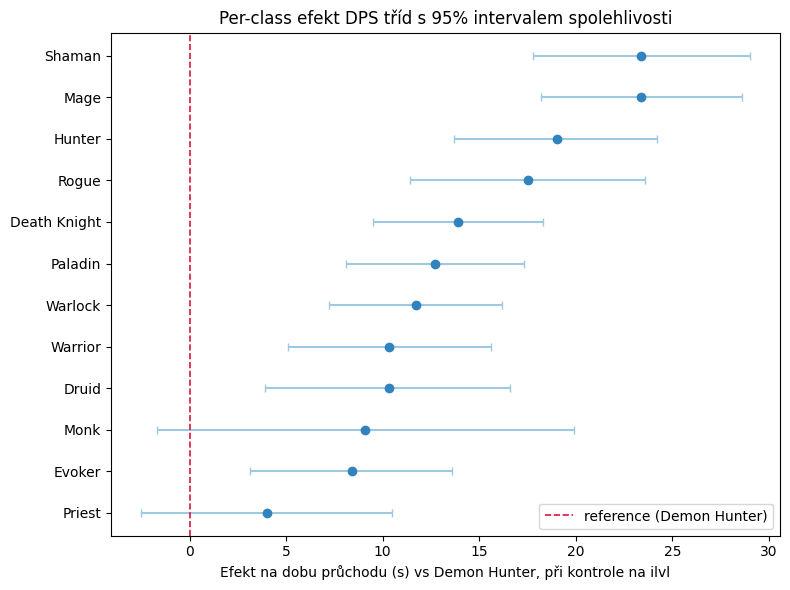

In [15]:
# Forest plot: bodový odhad + 95% CI pro každou DPS třídu
plot_data = class_effects.sort_values("efekt (s)")
positions = np.arange(len(plot_data))
errors_low = plot_data["efekt (s)"] - plot_data["CI dolni"]
errors_high = plot_data["CI horni"] - plot_data["efekt (s)"]

figure, axis = plt.subplots(figsize=(8, 6))
axis.errorbar(plot_data["efekt (s)"], positions, xerr=[errors_low, errors_high],
              fmt="o", color="#3182bd", ecolor="#9ecae1", capsize=3)
axis.axvline(0, color="crimson", ls="--", lw=1.2, label=f"reference ({REFERENCE_CLASS})")
axis.set_yticks(positions); axis.set_yticklabels(plot_data["DPS trida"])
axis.set_xlabel(f"Efekt na dobu průchodu (s) vs {REFERENCE_CLASS}, při kontrole na ilvl")
axis.set_title("Per-class efekt DPS tříd s 95% intervalem spolehlivosti")
axis.legend(); plt.tight_layout(); plt.show()

### 8.6 Pohled po specích (meta je obvykle konkrétní spec)

Class je hrubé měřítko, protože meta bývá jen jeden spec dané třídy. Mage je relevantní hlavně jako Frost, ne jako Arcane nebo Fire, Warlock jako Demonology, ne Affliction. Stejnou analýzu jako v 8.5 proto zopakuju na úrovni speců: každý DPS slot popíšu štítkem "class - spec", spočítám počty nezávisle na pořadí a jako referenci vezmu nejčastější spec (Demon Hunter - Devourer).

In [16]:
dps_spec_columns = ["dps_1_spec", "dps_2_spec", "dps_3_spec"]
# Sloučím class a spec do jednoho štítku, ať jsou specy jednoznačné napříč třídami
spec_labels = [full_data[class_col].astype(str) + " - " + full_data[spec_col].astype(str)
               for class_col, spec_col in zip(dps_class_columns, dps_spec_columns)]

dps_specs = sorted({label for column in spec_labels for label in column.unique() if "nan" not in label})
spec_counts = {spec: sum(column == spec for column in spec_labels).to_numpy() for spec in dps_specs}
runs_with_spec = {spec: int(sum(column == spec for column in spec_labels).astype(bool).sum()) for spec in dps_specs}

REFERENCE_SPEC = "Demon Hunter - Devourer"   # nejčastější DPS spec -> referenční úroveň
predictor_specs = [spec for spec in dps_specs if spec != REFERENCE_SPEC]

spec_design_columns = [np.ones(valid_rows.sum()), average_ilvl[valid_rows]]
spec_design_columns += [spec_counts[spec][valid_rows] for spec in predictor_specs]
spec_design_matrix = np.column_stack(spec_design_columns)
spec_column_names = ["intercept", "avg_group_ilvl"] + predictor_specs

# ordinary_least_squares je definovaná v sekci 8.5
spec_coefficients, spec_standard_errors, spec_r_squared = ordinary_least_squares(spec_design_matrix, clear_seconds[valid_rows])

spec_effect_rows = []
for index, name in enumerate(spec_column_names):
    if name in ("intercept", "avg_group_ilvl"):
        continue
    estimate = spec_coefficients[index]
    half_width = CONFIDENCE * spec_standard_errors[index]
    ci_low, ci_high = estimate - half_width, estimate + half_width
    spec_effect_rows.append({
        "DPS spec": name,
        "efekt (s)": round(estimate, 1),
        "CI dolni": round(ci_low, 1),
        "CI horni": round(ci_high, 1),
        "runu se specem": runs_with_spec[name],
        "lisi se od 0": "ano" if (ci_low > 0 or ci_high < 0) else "ne",
    })

spec_effects = pd.DataFrame(spec_effect_rows).sort_values("efekt (s)").reset_index(drop=True)
print(f"Reference: {REFERENCE_SPEC} (efekt 0). Kladný efekt = pomalejší než tento spec.")
print(f"Koeficient avg_group_ilvl: {spec_coefficients[1]:.2f} s na +1 ilvl   |   R² modelu (ilvl + specy): {spec_r_squared:.3f}")
spec_effects

Reference: Demon Hunter - Devourer (efekt 0). Kladný efekt = pomalejší než tento spec.
Koeficient avg_group_ilvl: -1.95 s na +1 ilvl   |   R² modelu (ilvl + specy): 0.036


,DPS spec,efekt (s),CI dolni,CI horni,runu se specem,lisi se od 0
0,Rogue - Outlaw,-0.1,-13.1,12.9,154,ne
1,Warrior - Arms,5.1,-1.3,11.6,759,ne
2,Priest - Shadow,5.4,-1.1,11.9,778,ne
3,Evoker - Augmentation,9.8,4.5,15.2,2207,ano
4,Druid - Feral,11.1,2.7,19.4,411,ano
5,Monk - Windwalker,11.5,0.7,22.3,224,ano
6,Warlock - Demonology,12.4,7.8,17.0,3372,ano
7,Druid - Balance,13.8,5.4,22.1,430,ano
8,Hunter - Marksmanship,13.9,5.3,22.4,414,ano
9,Paladin - Retribution,14.7,10.1,19.4,2597,ano


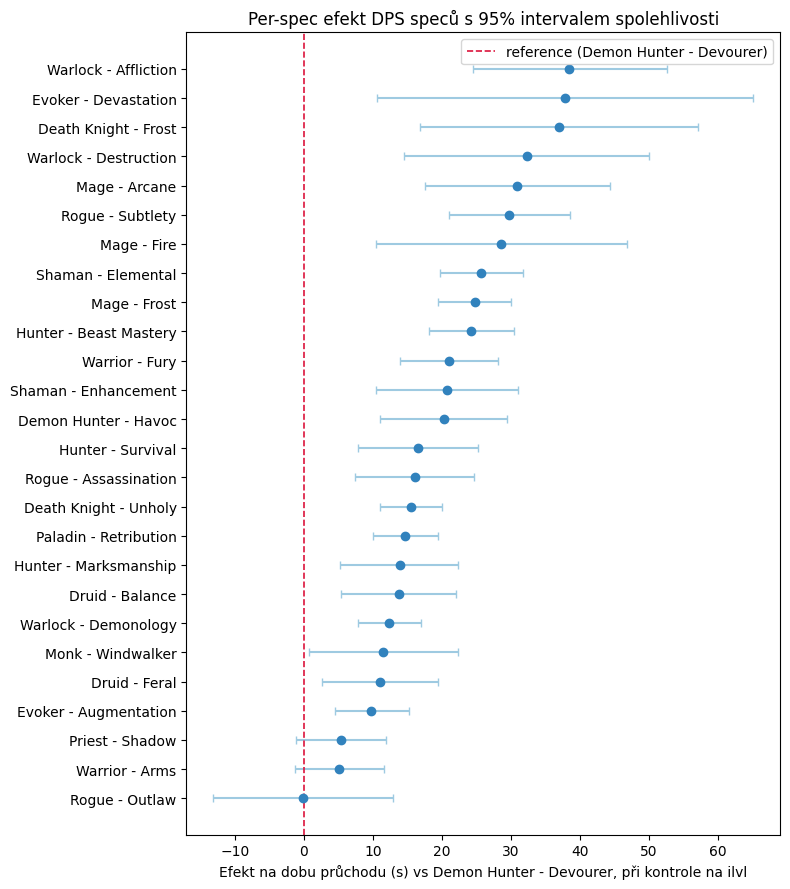

In [17]:
# Forest plot na úrovni speců (víc kategorií, proto vyšší obrázek)
spec_plot = spec_effects.sort_values("efekt (s)")
positions = np.arange(len(spec_plot))
errors_low = spec_plot["efekt (s)"] - spec_plot["CI dolni"]
errors_high = spec_plot["CI horni"] - spec_plot["efekt (s)"]

figure, axis = plt.subplots(figsize=(8, 9))
axis.errorbar(spec_plot["efekt (s)"], positions, xerr=[errors_low, errors_high],
              fmt="o", color="#3182bd", ecolor="#9ecae1", capsize=3)
axis.axvline(0, color="crimson", ls="--", lw=1.2, label=f"reference ({REFERENCE_SPEC})")
axis.set_yticks(positions); axis.set_yticklabels(spec_plot["DPS spec"])
axis.set_xlabel(f"Efekt na dobu průchodu (s) vs {REFERENCE_SPEC}, při kontrole na ilvl")
axis.set_title("Per-spec efekt DPS speců s 95% intervalem spolehlivosti")
axis.legend(); plt.tight_layout(); plt.show()

## 9. Diskuze výsledků

### Který model je nejlepší a proč?

Nejlepší model na testu je Random Forest (full) s RMSE 83.4 s (R² 0.043). Těsně za ním jsou SVR (84.2 s) a KNN (84.3 s), taky na feature setu full. Trojice nelineárních modelů (RF, SVR, KNN) tak poráží lineární modely (Ridge, Lasso a Linear kolem 86 až 87 s) i baseline. Dává to smysl: vztah mezi gearem či složením a časem není čistě lineární a tyhle modely zachytí mírné interakce, Random Forest navíc průměruje přes 300 stromů, čímž sníží rozptyl jednoho stromu. Rozdíly mezi nejlepšími modely jsou ale jen kolem 1 s, takže žádný výrazně nevyčnívá.

### Hlavní zjištění: predikovat se toho dá málo

Důležitější než pořadí modelů je absolutní úroveň R². I ten nejlepší model vysvětlí jen asi 4 % rozptylu doby průchodu a většina modelů má R² blízko nuly nebo záporné. Mezi top EU skupinami na +16 tedy gear ani složení dobu průchodu prakticky nepředpovídají. Celkem to sedí: rozsah dat je úzký (všichni hráči jsou špičkoví a gear je v podstatě zastropovaný) a o výsledném čase rozhoduje hlavně to, co v datech nemám, tedy provedení, počet smrtí, volba pullů a tras nebo denní forma.

### Došlo k přeučení (overfitting)?

Tady je potřeba být opatrný, protože naivní rozdíl mezi trénovací a testovací RMSE není čistý overfitting. Ukazuje to baseline: konstantní model s nulovou složitostí má train RMSE 76.7 s, ale test RMSE 87.9 s. Těch zhruba 11 s rozdílu vzniká posunem rozdělení v čase, protože chronologický split posílá do testu pozdější runy ze sezóny, kde se časy posunuly. Tahle mezera je společná všem modelům bez ohledu na složitost.

Skutečné přeučení poznám podle train RMSE výrazně nižší, než má baseline (76.7 s):
- Random Forest (full) má train RMSE 55.1 s (R² 0.484), ale test 83.4 s. Zapamatoval si šum trénovacích dat, což hluboké stromy dělají běžně.
- Random Forest na samotném ilvl je odstrašující případ. Na tréninku má R² 0.407, na testu ale R² -0.081, takže je horší než baseline. Silný model na šesti slabých numerických featurech se přeučí na šum v ilvl a generalizuje hůř než konstanta.
- Lineární modely (train RMSE kolem 73 až 76 s, tedy zhruba jako baseline) naopak nepřeučují. Jejich výkon na tréninku je sotva lepší než konstanta, protože signál je prostě slabý.

### Jak velký je rozdíl oproti baseline? Vyplatila se složitost?

Nejlepší model porazí baseline z 87.9 na 83.4 s, tedy o 4.5 s (asi 5 %). Je to reálné a konzistentní zlepšení, nelineární modely na full jsou spolehlivě pod baseline, ale malé. Odpověď na otázku, jestli se vyplatilo sáhnout po složitějším algoritmu, je proto spíš vlažná. Za cenu 300 stromů získám asi 5 % na RMSE a R² je pořád jen kolem 0.04. Z praktického hlediska je cennější samotné zjištění, že čas průchodu se z dostupných dat skoro předpovědět nedá, takže nasazovat sem složitý model nemá moc smysl.

### Výzkumná otázka: přidává složení něco nad ilvl?

Přidává, ale málo. Pro stejný model feature set full skoro vždy poráží ilvl:

| Model | ilvl | full | rozdíl |
|---|---|---|---|
| Random Forest | 88.7 | 83.4 | -5.3 |
| KNN | 85.8 | 84.3 | -1.5 |
| Ridge | 86.9 | 86.1 | -0.8 |
| SVR | 84.6 | 84.2 | -0.4 |
| Linear Regression | 86.9 | 87.1 | +0.2 |

Složení tedy nese malou prediktivní hodnotu, nejvíc u Random Forestu. Interpretace ale varuje před přeceněním:
- Ve feature importance Random Forestu dominuje ilvl (`avg_group_ilvl` kolem 0.15, jednotlivé ilvl kolem 0.08), zatímco class, spec a race jsou řádově slabší (kolem 0.01). Gear je hlavní, složení jen dolaďuje.
- Mezi nejsilnějšími koeficienty Ridge se objevují kuriózní rasy a specy (Pandaren, Zandalari Troll a podobně), které nemají mechanický důvod ovlivňovat čas. Spíš než reálný efekt to vypadá na zdánlivé korelace, což odpovídá skoro nulovému R².

Závěr k otázce: v rámci +16 přidává složení nad průměrný ilvl jen okrajový signál. V sekci 8.5 ale ukazuju, že nejde čistě o šum, ale o malý a konzistentní efekt favorizující meta třídu.

### Konkrétní třídy: vyplatí se někoho nebrat?

Analýza nezávislá na pořadí slotů (počty tříd místo `dps_1/2/3`, s kontrolou na `avg_group_ilvl`) dává ostřejší obrázek než OHE výše a odhalí konzistentní signál, který slotové kódování rozmělnilo do zdánlivých ras. Vůči nejčastější DPS třídě (Demon Hunter, sezónní meta) je každá jiná třída spojená s o něco pomalejším časem. Rozdíly jsou statisticky významné (většina 95% intervalů nezahrnuje nulu), ale malé, řádově 8 až 23 s, tedy zhruba 0.5 až 1.5 % z přibližně 1595s runu, a R² modelu je jen kolem 0.03.

Ke konkrétní otázce, jestli vyhodit Rogue místo Shamana: data to nepodporují. Efekt Rogue (+17.5 s vůči Demon Hunterovi) je menší než u Shamana (+23.4 s) i Mága (+23.4 s), takže Rogue je odhadem asi o 6 s rychlejší než Shaman, navíc se jejich intervaly spolehlivosti překrývají, takže ten rozdíl není průkazný. Jednoznačně nejrychlejší je jen Demon Hunter.

Tyhle efekty je ale nutné brát jako asociace, ne jako kauzalitu. Demon Hunter je meta DPS a stackují ho nejlepší skupiny, kdežto off-meta třídy korelují s o něco méně sehranými skupinami, a tyhle dvě věci od sebe v datech neoddělím. Vyřadit kompetentního hráče kvůli jeho třídě tedy podle těchto dat opodstatněné není. Snad jen vyloženě tryhardové stackování Demon Hunterů by mělo nějaký smysl, ale bavíme se o jednom procentu času.

### Pohled po specích (8.6)

Spec-level analýza potvrzuje to hlavní: meta je věc konkrétního specu, ne celé třídy, a rozdíly uvnitř jedné třídy jsou často větší než mezi třídami. Warlock Demonology (kolem +12 s) je výrazně rychlejší než Affliction (kolem +39 s) nebo Destruction (kolem +32 s), Death Knight Unholy (+16 s) překonává Frost DK (+37 s) a Rogue má extrémní rozptyl, od Outlawa (kolem 0 s, tedy prakticky stejně rychlý jako referenční Demon Hunter) až po Subtlety (+30 s). To přesně sedí na intuici, že nejde o třídu, ale o spec. R² modelu navíc povyrostlo z 0.026 na 0.036, takže spec nese o trochu víc informace než hrubá class.

Příběh ale zůstává stejný. Nejrychlejší specy jsou zároveň ty nejhranější (Devourer, Demonology, Unholy, Augmentation, Retribution), zatímco pomalé specy jsou vesměs vzácné a mají široké intervaly spolehlivosti (Mage Fire n=76, Warlock Destruction n=74, Frost DK n=61). Že je nejhranější spec i nejrychlejší, jde vyložit dvěma směry, které od sebe v datech neoddělím: buď je rychlý, protože je dobrý, nebo se jeví rychlý, protože ho hrají ti nejlepší. A magnitudy zůstávají malé, i ten nejpomalejší spec ztrácí kolem 38 s, tedy zhruba 2 % z runu, a všechny tyhle runy se přesto vešly do časového limitu.

### Omezení
- Výběrový bias a úzký rozsah dat: jen top-ranked EU populace, takže malý rozptyl skillu i gearu a málo co predikovat.
- Arbitrární pořadí DPS (`dps_1/2/3`): model může vážit pořadí, které nemá význam. Korektnější je reprezentace přes počty speců, kterou používám v sekci 8.5.
- Drift v čase: chronologický split posouvá rozdělení (vidět už na baseline), což zvětšuje testovací chyby u všech modelů.


## 10. Závěr

Na testu překonává baseline (RMSE 87.9 s) všechny reálné modely kromě přeučeného Random Forestu na samotném ilvl. Nejlepší je Random Forest (full) s RMSE 83.4 s, tedy asi 5 % nad baseline, ale s R² jen 0.043. Složení skupiny přidává nad průměrný ilvl jen okrajový signál. Analýza nezávislá na pořadí (sekce 8.5 a 8.6) sice najde malý a statisticky významný efekt ve prospěch meta speců, kde jsou nejrychlejší skupiny s Demon Huntery (spec Devourer), ale jde o zhruba procento času a z velké části o asociaci s kvalitou skupiny, ne o kauzální vliv třídy. Konkrétně Rogue není pomalejší než Shaman, takže premisu pro elitistické vyřazování tříd data nepodporují.

Hlavní závěr projektu je tedy spíš střízlivý: mezi špičkovými EU skupinami na klíči +16 se doba průchodu Pit of Saron z gearu ani složení skoro předpovědět nedá, rozhoduje hlavně provedení a faktory mimo dostupná data. Za mě je na celém úkolu nejcennější právě tohle čtení čísel: mít smysluplnou baseline, odlišit drift od overfittingu a slabý signál se nesnažit nafouknout.
